# **Learning to Control SPOT using Camera Inputs**



SPOT, the robot dog,   navigate autonomously in indoor environments by following crude instructions from a human user: FORWARD, LEFT, and RIGHT. Its main sensor  is a forward-looking camera mounted at its head. SPOT uses the real-time camera images to understand the environment and decide the exact motion required to follow the user's instructions as closely as possible. 

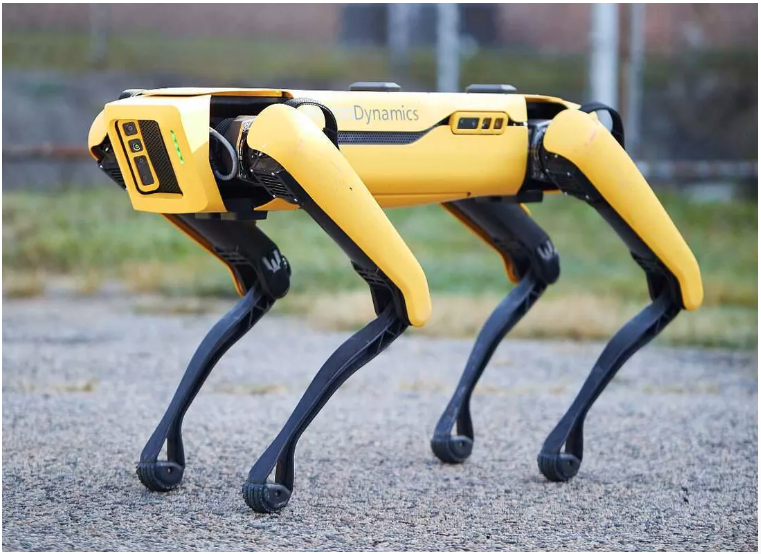


### **Overview**

This Colab notebook guides you through the task of learning to control SPOT for navigating in the SoC COM1 building. Here is the setup. A user signals high-level *intentions*,  FORWARD, LEFT, and RIGHT, to command SPOT to follow a route. Spot needs to determine its own real-time control, i.e., angular velocities, conditioned on the  user intention as well as real-time observations of the environment obtained from its front camera. You will train a neural network for the robot to complete this task.

You will use supervised learning, or also called "behaviour cloning". You will have access to a human demonstration dataset, constructed by a human expert directly controlling SPOT using a joystick, to navigate according to the high-level intention signaled by a user. The dataset contains 110,000   camera image frames and user intentions.  Each frame is labelled with the angular velocity that SPOT undertakes at the cooresponding situation. Labels of angular velocities are discretized into five bins, cooresponding to five different control classes: "hard left turn", "slight left turn", "forward", "slight right turn", and "hard right turn". Given the discretized labels, the control task becomes the problem of learning a mapping from the camera observation and the user intention to a suitable class of robot control. It is thus treated as a standard image classification task from the machine learning standpoint. 

After training, the robot would exhibit roughly the following behaviors:
* make hard turns at junctions or to avoid immediate collisions with  obstacles,
* make slight turns to conform to the shape of the corridor or prepare for hard turns,
* go straight when its heading is well-aligned with a clear corridor.

Consistent failures to  choose proper control would cause the robot to crash into the wall, obstacles, or people, while occasional failures may be recoverable.


This notebook consists of five main steps, to be executed in order.

1. *Preparation*. Check and set up the running environment: mount the google drive, create a project folder, install package dependency, ...

2. *Basic CNN Model*. Define a simple 
convolutional neural network (CNN) model that maps input images to descretized control decisions.

3. *Data Loading*. Provide a helper class to load the data for training the agent.

4. *Basic CNN Model Training*.  Run the script provided to train a basic CNN model. 

5. *Improving Prediction Performance*. Improve basic CNN model to achieve better performance for behaviour cloning in terms of the prediction accuracy.


**Remarks**
* If Colab is new to you, it may be worthwhile to go over the quick [introduction](https://colab.research.google.com/notebooks/intro.ipynb).

* The five steps should be executed **in order**, unless you are familiar with Colab and know what you are doing.

* Training with GPUs is much faster than that with CPUs only:  under the Colab notebook dropdown menu,  choose `Runtime/Change runtime type/GPU`.

* Maintain good Internet connection throughout to avoid disconnecting from the Colab.

* Do not idle your computer, as Colab automatically disconnects GPUs if the idle time is too long.

* If you have a good GPU on your personal computer, it is recommended to download the colab sheet as a python file and test your code on your local machine. The computational performance is usually better.



### **1. Preparation**



**Check Python version.**

In [16]:
!python -V

Python 3.7.12


**Check Cuda version.**

In [17]:
!nvcc -V

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2020 NVIDIA Corporation
Built on Mon_Oct_12_20:09:46_PDT_2020
Cuda compilation tools, release 11.1, V11.1.105
Build cuda_11.1.TC455_06.29190527_0


**Mount the Google drive.**

Mount your Google drive to store the dataset and the trained models.
Execute the cell below. Visit this [URL](https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly&response_type=code) to retrieve the authorization code and  enter the code at the prompt. 

In [18]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Create a project directory**

In [19]:
from os import path, chdir, getcwd, mkdir

# Choose a project name
projectName = "BehaviourCloning"

# Project directory is in My Drive
projectDirectory = "/content/drive/My Drive/" + projectName

# Checks if cwd is in content folder
if getcwd() == "/content":
  # Makes project directory if it does not exist
  if not path.isdir(projectDirectory):
    mkdir(projectDirectory)
    print(f"Project {projectName} has been created!")
  else:
    print(f"Project {projectName} already exist!")
  # Changes to project directory
  chdir(projectDirectory)

print(f"The current working directory is {getcwd()}")

The current working directory is /content/drive/My Drive/BehaviourCloning


**Install dependencies.**

In [20]:
pip install torch torchvision

In [21]:
pip install opencv-python

**Check GPU usage.**

In [22]:
# Check if runtime uses GPU
import torch

gpu_name = torch.cuda.get_device_name(0)
print("Using GPU", gpu_name)

Using GPU Tesla K80


**Download the data set to your Google drive.**

The dataset requires about 400MB space. Please prepares sufficient space for downloading.

In [23]:
from os import path, chdir, getcwd, mkdir
projectDirectory = "/content/drive/My Drive/BehaviourCloning"
chdir(projectDirectory)

!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=16DOwYORpKiXffxgzOIsfq6eA1qd6FW5i' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=16DOwYORpKiXffxgzOIsfq6eA1qd6FW5i" -O data.zip 

--2021-10-20 07:01:19--  https://docs.google.com/uc?export=download&confirm=xz9f&id=16DOwYORpKiXffxgzOIsfq6eA1qd6FW5i
Resolving docs.google.com (docs.google.com)... 64.233.184.139, 64.233.184.138, 64.233.184.113, ...
Connecting to docs.google.com (docs.google.com)|64.233.184.139|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://doc-08-0s-docs.googleusercontent.com/docs/securesc/1o6pha16qnuh47qat30r47inv7je5vsk/21ldo6bbafqfl3cuoikr31vf252mnlc0/1634713275000/16928826242900815371/10083961553657669259Z/16DOwYORpKiXffxgzOIsfq6eA1qd6FW5i?e=download [following]
--2021-10-20 07:01:19--  https://doc-08-0s-docs.googleusercontent.com/docs/securesc/1o6pha16qnuh47qat30r47inv7je5vsk/21ldo6bbafqfl3cuoikr31vf252mnlc0/1634713275000/16928826242900815371/10083961553657669259Z/16DOwYORpKiXffxgzOIsfq6eA1qd6FW5i?e=download
Resolving doc-08-0s-docs.googleusercontent.com (doc-08-0s-docs.googleusercontent.com)... 64.233.166.132, 2a00:1450:400c:c09::84
Connecting

**Unzip the dataset**

It may take few minutes to finish.

In [24]:
!unzip -o data.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/454539.jpg       
  inflating: images/967320.jpg       
  inflating: images/317008.jpg       
  inflating: images/23826.jpg        
  inflating: images/1085186.jpg      
  inflating: images/1050898.jpg      
  inflating: images/522312.jpg       
  inflating: images/263225.jpg       
  inflating: images/933635.jpg       
  inflating: images/433844.jpg       
  inflating: images/330417.jpg       
  inflating: images/912454.jpg       
  inflating: images/727662.jpg       
  inflating: images/513243.jpg       
  inflating: images/980791.jpg       
  inflating: images/412835.jpg       
  inflating: images/403584.jpg       
  inflating: images/203240.jpg       
  inflating: images/429351.jpg       
  inflating: images/322949.jpg       
  inflating: images/417338.jpg       
  inflating: images/613329.jpg       
  inflating: images/321548.jpg       
  inflating: images/26958.jpg        
  inflating: images/312096.jpg       

**Remove the data.zip file to save space**

In [25]:
projectDirectory = "/content/drive/My Drive/BehaviourCloning"
chdir(projectDirectory)
!rm data.zip # to save spacee NVIDIA® Tesla® K80 Accelerator dramatically lowers data center costs by delivering exceptional performance with fewer, more powerful servers. It's engineered to boost throughput in real-world applications by 5-10x, while also saving customers up to 50% for an accelerated data center compared to a CPU-only 

### **2. About the Dataset**

Our dataset consists of ~110k time frames of data collected by human controlling the SPOT robot to navigate in COM1, SOC. Features of each data point consist of the front-camera image at the cooresponding time frame and the intention (LEFT, FORWARD, RIGHT) the user had specified. The label of each data point is the control that SPOT conducted at the time frame to achieve the user intention. Each label falls in five control classes: "hard left turn", "slight left turn", "forward", "slight right turn", and "hard right turn", which coorespond to five evenly divided intervals of angular velocities. Particularly, angular velocities of hard turns have absolute values <= 0.7 and > 0.42 of the turning limit of SPOT; slight turns have absolute values <= 0.42 and > 0.24; forward motion have values <= 0.24.

Given the user intenton as context, the relationship between the camera observation and the robot control is still complex. For instance, human may command a LEFT intention far before reaching a junction, but the robot should keeping moving forward and start to turn only when at the junction. In other cases when obstacles in the corridor block the robot's way, the robot will have to avoid collisions in a way possibly contradicting with the user intention. The robot thus has to understand the environment according camera observations and determine the most appropriate behaviours.

Here are a few examples from the dataset:

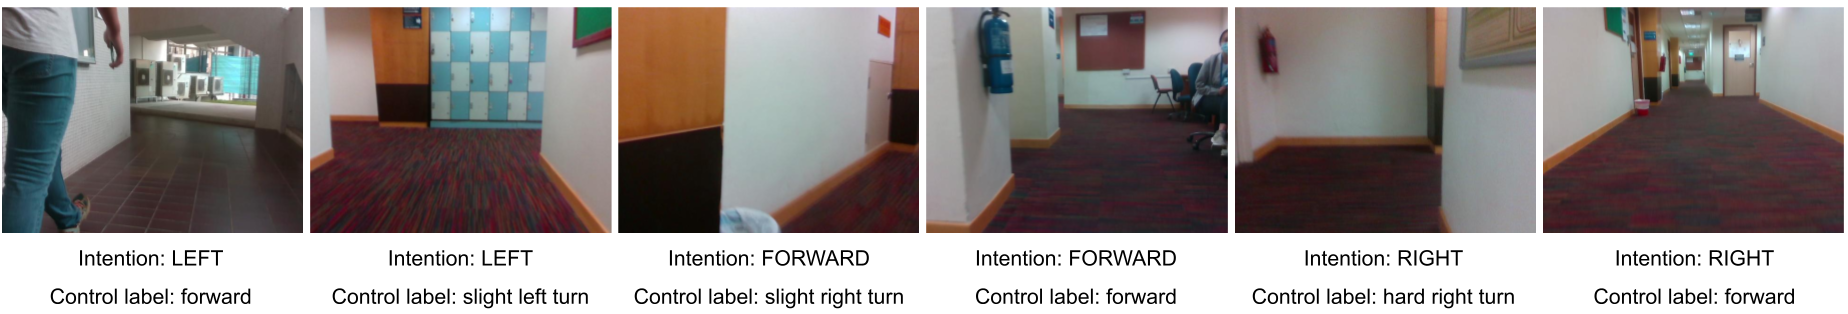

### **3. Basic CNN Model**

**Define the convolutional neural network (CNN) model for control prediction.**

<!-- In the earliner lecture, we talked about linear regression: fit input-output data pairs to a linear function.  -->
Here, we build a neural network that takes camera images and user intentions as input and outputs categorical distributions over the five control classes.
A linear function is not sufficient to capture the complex relationship between  input *images* and output control labels (angular velocities).   Instead, we use a neural network, which is capable of representing complex nonlinear functions. The neural network model consists of several convolution layers to extract featurs from  the images and full connnected layers to map image features to the final output. We additionally use three different output heads to condition on different intentions.

Below defines a simple CNN model for demonstration.




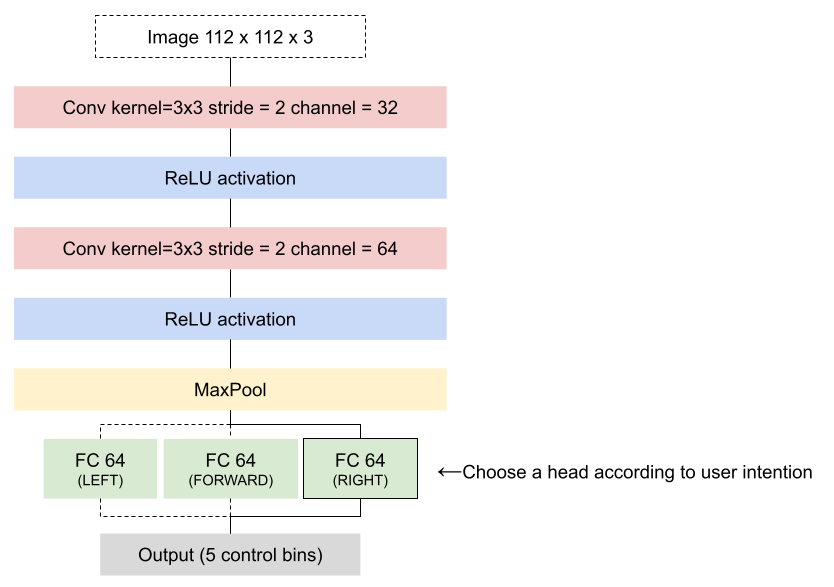

In [26]:
import torch.nn as nn
import torch.nn.functional as F
import torch
from torchvision import models

# Pretrained AlexNet model
alexnet = models.alexnet(pretrained=True)

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class MyModel(nn.Module):

    def __init__(self, num_bins=5):
        super().__init__()
        self.num_bins = num_bins

        # Build the CNN feature extractor
        self.cnn = nn.Sequential(
            *list(alexnet.features.children()),
            alexnet.avgpool
        )
        
        # FC layers
        self.fc = nn.Sequential(
            # Add intention to in_features
            nn.Dropout(),
            nn.Linear(in_features=256 * 6 * 6 + 3,out_features=4096),
            *list(alexnet.classifier.children())[2:-1],
            nn.Linear(4096, num_bins)
        )    

        print(f'A simple learner. WARNING: For training efficiency, '
              f'it assumes the intention is the same for all samples in a batch. ')

    def forward(self, image, intention):
        # Map images to feature vectors
        feature = self.cnn(image).flatten(1)
        # Cast intention to one-hot encoding 
        intention = intention.unsqueeze(1)
        onehot_intention = torch.zeros(intention.shape[0], 3, device=intention.device).scatter_(1, intention, 1)
        # Predict control
        control = self.fc(torch.cat((feature, onehot_intention), dim=1)).view(-1, self.num_bins)
        # Return control as a categorical distribution
        return control

You can stack more convolutional layers (`nn.conv2d`) in the feature extractor `self.cnn` to make the model deeper. You may also change the number of output channels (`out_channels`) to make the CNN wider. Deeper and wider networks are generally more expressive and can represent more complex functions. 

Note that when modifying the architecture, you have to make sure that the `in_channels` of a layer equals to the `out_channels` of its preceding layer.



### **4. Data Loading**

In the following code, we create a data loader `MyDataset` to load our dataset from the hard disk to the memory. The Python class inherits the standard PyTorch `Dataset` class. It will return us a mini-batch of randomly sampled data at every `enumerate` operation. You will see the usage in our training code.   

In [30]:
import os
import cv2
import random
import math
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import Sampler
from torchvision import transforms
from torchvision.transforms import *
import sys
import torch
from math import pi

angle = math.pi / 18 # 20 degrees

def read_image(path):
    return Image.open(path)


class MyDataset(Dataset):
    
    INTENTION_MAPPING = {'forward': 0, 'left': 1, 'right': 2}
    MAX_VELOCITY = 0.7
    MIN_VELOCITY = -0.7

    def __init__(self, is_train=True, num_bins=5):
        self.bin_size = (self.MAX_VELOCITY - self.MIN_VELOCITY) / num_bins
        self.is_train = is_train

        self.data_dir = '.'
        if is_train:
            self.data = pd.read_csv(os.path.join(self.data_dir, 'train.txt'), sep='  ')
            # self.data = pd.read_csv(os.path.join(self.data_dir, 'val.txt'), sep=' ')
        else:
            self.data = pd.read_csv(os.path.join(self.data_dir, 'val.txt'), sep=' ')

        self.preprocess = Compose([
            Resize((112, 112)),
            ToTensor(),
            Normalize(mean=[0.5071, 0.4866, 0.4409], std=[0.2675, 0.2565, 0.2761])
        ])
        
        print(f'loaded data from {self.data_dir}. dataset size {len(self)}')

    def discretize_control(self, control):
        return int((control - self.MIN_VELOCITY) / self.bin_size)

    def __getitem__(self, idx):
        # print(self.data.iloc[idx])
        # sys.stdout.flush()
        frame, _, _, angular_velocity, intention = self.data.iloc[idx]
        image = self.preprocess(read_image(os.path.join(self.data_dir, 'images', f'{frame}.jpg')))
        intention = torch.tensor(self.INTENTION_MAPPING[intention])
        label = torch.tensor(self.discretize_control(angular_velocity))

        if self.is_train:
            image, intention, label = self.rand_transform(image, intention, label)

        return image, intention, label

    def rand_transform(self, image, intention, label):
        image, intention, label = self.rand_flip(image, intention, label)
        transforms = RandomApply(torch.nn.ModuleList([
            RandomRotation(angle),
            RandomResizedCrop(size=(112,112),scale=(0.5,1)),
            GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
            ColorJitter(brightness=0.5),
            RandomPerspective(),
            RandomAutocontrast(),
        ]))
        image = transforms(image)
        return image, intention, label

    def rand_flip(self, image, intention, label, prob=0.5):
       if random.random() > prob:
          return image, intention, label
       f_intention = 2 - intention
       f_label = 4 - label
       f_image = RandomHorizontalFlip(1).forward(image)
       return f_image, f_intention, f_label

    def __len__(self):
        return len(self.data)

### **5. Basic CNN Model Training**



**Set the working directory.**

In [31]:
from os import path, chdir, getcwd, mkdir
projectDirectory = "/content/drive/My Drive/BehaviourCloning"
chdir(projectDirectory)

**Start training.**

The first epoche is slow. With data caching, from the 2nd epoch it trains much faster.



In [32]:
import time
import torch
import multiprocessing as mp
from torch.optim.lr_scheduler import ReduceLROnPlateau
# from dataset import MyDataset
# from model import MyModel
import re


class AverageMeter(object):
    """
    A utility class to compute statisitcs of losses and accuracies
    """

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def get_lr(optimizer):
    '''
    Get the current learning rate
    '''
    for param_group in optimizer.param_groups:
        return param_group['lr']


def topk_accuracy(k, outputs, targets):
    """
    Compute top k accuracy
    """
    batch_size = targets.size(0)

    _, pred = outputs.topk(k, 1, True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1))
    n_correct_elems = correct.type(torch.FloatTensor).sum().item()

    return n_correct_elems / batch_size


def train():
    batch_size = 16
    num_epochs = 10
    num_workers = 2
    num_bins = 5
    ckpt = ""
    start_epoch = 0

    model = MyModel(num_bins)
    # model = model.cuda().float()
    model = nn.DataParallel(model.cuda().float())

    if ckpt:
        pretrained_dict = torch.load(ckpt)
        model.load_state_dict(pretrained_dict)
        regex = re.compile(r'\d+')
        start_epoch = int(regex.search(ckpt).group(0)) + 1

    train_set = MyDataset(is_train=True, num_bins=num_bins)
    validation_set = MyDataset(is_train=False, num_bins=num_bins)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=batch_size, num_workers=num_workers, pin_memory=True, shuffle=True)
    validation_loader = torch.utils.data.DataLoader(
        validation_set, batch_size=batch_size, num_workers=num_workers, pin_memory=True, shuffle=False)

    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay=0.001, momentum=0.5)
    # optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=0.001)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=1, factor=0.3)

    # training loop
    for epoch in range(start_epoch, start_epoch + num_epochs):
        start_time = time.time()
        train_loss, val_loss = AverageMeter(), AverageMeter()
        train_acc, val_acc = AverageMeter(), AverageMeter()

        # train loop
        model.train()
        for i, (image, intention, label) in enumerate(train_loader):
            image, intention, label = image.cuda(), intention.cuda(), \
                label.cuda().view(-1)

            prediction = model(image, intention)

            loss = criterion(prediction, label)
            train_loss.update(loss.item())

            acc = topk_accuracy(2, prediction, label)
            train_acc.update(acc)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if i % 100 == 99:
                print(f'training: iteration {i} / {len(train_loader)}, avg train loss = {train_loss.avg:.4f}, '
                      f'train accuracy {train_acc.avg:.4f}')

        # validation
        model.eval()
        for i, (image, intention, label) in enumerate(validation_loader):
            image, intention, label = image.cuda(), intention.cuda(), \
                label.cuda().view(-1)            
            with torch.no_grad():
                prediction = model(image, intention)

                loss = criterion(prediction, label)
                val_loss.update(loss.item())

                acc = topk_accuracy(2, prediction, label)
                val_acc.update(acc)

            if i % 100 == 99:
                print(f'validation: iteration {i} / {len(validation_loader)}, avg val loss = {val_loss.avg:.4f}, '
                      f'val accuracy {val_acc.avg:.4f}')

        # epoch summary
        print(f'Epoch {epoch}, train error {train_loss.avg:.4f}, val error {val_loss.avg:.4f}. '
              f'Train acc = {train_acc.avg:.4f}, val acc = {val_acc.avg:.4f}. '
              f'Time cost {(time.time() - start_time) / 60:.2f} min.\n')

        # lr scheduler
        scheduler.step(val_loss.avg)

        # checkpoint
        if epoch % 2 == 1:
            torch.save(model.state_dict(), f'ckpt_e{epoch}.pth')


if __name__ == "__main__":
    train()


A simple learner. WARNING: For training efficiency, it assumes the intention is the same for all samples in a batch. 


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:33: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


loaded data from .. dataset size 97000
loaded data from .. dataset size 10000


/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:594: UserWarning: torch.lstsq is deprecated in favor of torch.linalg.lstsq and will be removed in a future PyTorch release.
torch.linalg.lstsq has reversed arguments and does not return the QR decomposition in the returned tuple (although it returns other information about the problem).
To get the qr decomposition consider using torch.linalg.qr.
The returned solution in torch.lstsq stored the residuals of the solution in the last m - n columns of the returned value whenever m > n. In torch.linalg.lstsq, the residuals in the field 'residuals' of the returned named tuple.
The unpacking of the solution, as in
X, _ = torch.lstsq(B, A).solution[:A.size(1)]
should be replaced with
X = torch.linalg.lstsq(A, B).solution (Triggered internally at  /pytorch/aten/src/ATen/LegacyTHFunctionsCPU.cpp:389.)
  res = torch.lstsq(b_matrix, a_matrix)[0]
/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:594

training: iteration 99 / 6063, avg train loss = 1.6085, train accuracy 0.4081
training: iteration 199 / 6063, avg train loss = 1.6060, train accuracy 0.4259
training: iteration 299 / 6063, avg train loss = 1.6010, train accuracy 0.4481
training: iteration 399 / 6063, avg train loss = 1.5939, train accuracy 0.4628
training: iteration 499 / 6063, avg train loss = 1.5850, train accuracy 0.4745
training: iteration 599 / 6063, avg train loss = 1.5763, train accuracy 0.4872
training: iteration 699 / 6063, avg train loss = 1.5662, train accuracy 0.5004
training: iteration 799 / 6063, avg train loss = 1.5538, train accuracy 0.5140
training: iteration 899 / 6063, avg train loss = 1.5429, train accuracy 0.5227
training: iteration 999 / 6063, avg train loss = 1.5342, train accuracy 0.5325
training: iteration 1099 / 6063, avg train loss = 1.5264, train accuracy 0.5420
training: iteration 1199 / 6063, avg train loss = 1.5167, train accuracy 0.5509
training: iteration 1299 / 6063, avg train loss = 1

...

training: iteration 99 / 6063, avg train loss = 0.9223, train accuracy 0.8369
training: iteration 199 / 6063, avg train loss = 0.9517, train accuracy 0.8319
training: iteration 299 / 6063, avg train loss = 0.9363, train accuracy 0.8354
training: iteration 399 / 6063, avg train loss = 0.9381, train accuracy 0.8331
training: iteration 499 / 6063, avg train loss = 0.9372, train accuracy 0.8309
training: iteration 599 / 6063, avg train loss = 0.9381, train accuracy 0.8293
training: iteration 699 / 6063, avg train loss = 0.9430, train accuracy 0.8291
training: iteration 799 / 6063, avg train loss = 0.9404, train accuracy 0.8313
training: iteration 899 / 6063, avg train loss = 0.9367, train accuracy 0.8336
training: iteration 999 / 6063, avg train loss = 0.9407, train accuracy 0.8323
training: iteration 1099 / 6063, avg train loss = 0.9389, train accuracy 0.8324
training: iteration 1199 / 6063, avg train loss = 0.9355, train accuracy 0.8339
training: iteration 1299 / 6063, avg train loss = 0

/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:594: UserWarning: torch.lstsq is deprecated in favor of torch.linalg.lstsq and will be removed in a future PyTorch release.
torch.linalg.lstsq has reversed arguments and does not return the QR decomposition in the returned tuple (although it returns other information about the problem).
To get the qr decomposition consider using torch.linalg.qr.
The returned solution in torch.lstsq stored the residuals of the solution in the last m - n columns of the returned value whenever m > n. In torch.linalg.lstsq, the residuals in the field 'residuals' of the returned named tuple.
The unpacking of the solution, as in
X, _ = torch.lstsq(B, A).solution[:A.size(1)]
should be replaced with
X = torch.linalg.lstsq(A, B).solution (Triggered internally at  /pytorch/aten/src/ATen/LegacyTHFunctionsCPU.cpp:389.)
  res = torch.lstsq(b_matrix, a_matrix)[0]
/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:594

training: iteration 99 / 6063, avg train loss = 0.9272, train accuracy 0.8319
training: iteration 199 / 6063, avg train loss = 0.8928, train accuracy 0.8400
training: iteration 299 / 6063, avg train loss = 0.8884, train accuracy 0.8402
training: iteration 399 / 6063, avg train loss = 0.8934, train accuracy 0.8394
training: iteration 499 / 6063, avg train loss = 0.8920, train accuracy 0.8400
training: iteration 599 / 6063, avg train loss = 0.8883, train accuracy 0.8421
training: iteration 699 / 6063, avg train loss = 0.8878, train accuracy 0.8421
training: iteration 799 / 6063, avg train loss = 0.8859, train accuracy 0.8423
training: iteration 899 / 6063, avg train loss = 0.8841, train accuracy 0.8427
training: iteration 999 / 6063, avg train loss = 0.8836, train accuracy 0.8432
training: iteration 1099 / 6063, avg train loss = 0.8845, train accuracy 0.8432
training: iteration 1199 / 6063, avg train loss = 0.8814, train accuracy 0.8451
training: iteration 1299 / 6063, avg train loss = 0

/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:594: UserWarning: torch.lstsq is deprecated in favor of torch.linalg.lstsq and will be removed in a future PyTorch release.
torch.linalg.lstsq has reversed arguments and does not return the QR decomposition in the returned tuple (although it returns other information about the problem).
To get the qr decomposition consider using torch.linalg.qr.
The returned solution in torch.lstsq stored the residuals of the solution in the last m - n columns of the returned value whenever m > n. In torch.linalg.lstsq, the residuals in the field 'residuals' of the returned named tuple.
The unpacking of the solution, as in
X, _ = torch.lstsq(B, A).solution[:A.size(1)]
should be replaced with
X = torch.linalg.lstsq(A, B).solution (Triggered internally at  /pytorch/aten/src/ATen/LegacyTHFunctionsCPU.cpp:389.)
  res = torch.lstsq(b_matrix, a_matrix)[0]
/usr/local/lib/python3.7/dist-packages/torchvision/transforms/functional.py:594

training: iteration 99 / 6063, avg train loss = 0.8369, train accuracy 0.8544
training: iteration 199 / 6063, avg train loss = 0.8628, train accuracy 0.8491
training: iteration 299 / 6063, avg train loss = 0.8525, train accuracy 0.8471
training: iteration 399 / 6063, avg train loss = 0.8598, train accuracy 0.8470
training: iteration 499 / 6063, avg train loss = 0.8510, train accuracy 0.8514
training: iteration 599 / 6063, avg train loss = 0.8470, train accuracy 0.8531
training: iteration 699 / 6063, avg train loss = 0.8480, train accuracy 0.8514
training: iteration 799 / 6063, avg train loss = 0.8491, train accuracy 0.8523
training: iteration 899 / 6063, avg train loss = 0.8442, train accuracy 0.8559
training: iteration 999 / 6063, avg train loss = 0.8460, train accuracy 0.8552
training: iteration 1099 / 6063, avg train loss = 0.8461, train accuracy 0.8549
training: iteration 1199 / 6063, avg train loss = 0.8455, train accuracy 0.8544
training: iteration 1299 / 6063, avg train loss = 0

This is our main training code. It performs training in the term of "epochs", where each epoch represents enumerating the full training dataset. In each epoch, we first train our model using mini batch gradient descent, then evaluate our model using the test data. For every two epochs, we save a checkpoint of our model to the hard disk.

The main hyper-parameters that need to be tuned for the learning task includes the learning rate ("lr" parameter of the optimizer), the size of mini batches ("batch_size"), and the L2 regularization factor ("weight_decay" parameter of the optimizer).

### **6. Improving the Model**

The basic CNN model does not work very well on the training data. After 10 epochs of training, it achieves about 53% top-2 classification accuracy on the validation dataset over 5 angular velocity bins. Now, your task is to investigate why the basic CNN model does not perform well and improve the model to achieve higher prediction accuracy. Some specific suggestions are given below.





**Tune the learning algorithm.**  Hyperparameter tuning is important to neural network training. Try to adjust the following parameters in section 5 "basic CNN model training":

- Choice of [optimizer](https://pytorch.org/docs/stable/optim.html) (SGD, Adam, AdamW (Adam with proper weight decay), ...)
- Learning rate (0.1, 0.01, 0.001, 0.0001, ...)
- Number of epochs (should be sufficient to achieve converge)
- Batch size (32, 64, 128, 256, ...) (optional)

The learning rate typically has the largest impact on performance. When the learning rate is too large, it leads to unstable training (loss fluctuating or frozen at a high level). When it is too small, it leads to inefficient training (loss decreasing very slowly). You need to identify the best learning rate to allow both stable and efficient training.

The choice of optmizer can also largely affect the training and validation performance. Some optimizers perform better on training, while some optimizers are good at generalization. Note that the learning rate needs to be re-tuned after changing the optimizer.

**Improve feature extraction.** A good image feature extractor is key to good performance. Using deeper (with more layers) and wider (with more channels) networks typically make the feature extractor more powerful. However, when there are too many trainable parameters in a network, it also becomes susceptible to ["overfitting"](https://d2l.ai/chapter_multilayer-perceptrons/underfit-overfit.html#underfitting-or-overfitting), i.e., the model fits the training set perfectly (low loss, high accuracy) but fails to generalize to the validation set (high loss, low accuracy). 

You need to determine the optimal depth and the width of your feature extractor to acheive the best performance on the validation set.









There are many other techniques to improve  classification performance. Two common ones are described below. You may try these two or any others to improve the  performance further, particularly, for extra credits.

**Augment the data (optional)**. The augmentation technique artificially expands the size of a training dataset by creating modified versions of images. It creates variations of the images that can improve the  model's ability to generalize. 
You can augment the images by transforming the content, for example:
- Fliping the input image horizontally (as well as the user intention and the angular velocity label). This produces data for a "mirrored" environment.
- Slightly translating or rotating the image. This emulates slight variations of the orientation of SPOT's body. You may need to slightly crop the edges of input images to eliminate empty pixels produced by image transformation.
- Other meaningful transformations to introduce variantion to images in the dataset. 

Transformations in [`torchvision.transforms`](https://pytorch.org/vision/stable/auto_examples/plot_transforms.html#sphx-glr-auto-examples-plot-transforms-py) allows you to easily perform various types of image transformations. You can customize your data augmentation by adding more random transformations to `self.preprocessor`.

**Regularization (optional).**
If overfitting unfortunately happens, you can try the following techniques to adddress it and improve the generalization of your model:
- [L2 reguarization or weight decay](https://d2l.ai/chapter_multilayer-perceptrons/weight-decay.html). Weight decay regulates the weights of your network to be small values so that the model generalizes better. The scaling factor of the regularization term is controlled by the `weight_decay` parameter of the optimizer.
- [Dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) (nn.Dropout and nn.Dropout2d). Dropout randomly drops out some activations in the cooresponding hidden layer during training. This makes the network more difficult to train, but often easier to generalize.


### **Submission**



Create a single zip file `YourMatricNumber.zip` (e.g., `A01234567.zip` ) containg the following:

1. Colab notebook
 * Download your entire Colab notebook. Save it as an ipynb file and name it `YourMatricNumber-Notebook.ipynb`.
2. Neural network model class
  
  This file will be used to load your pretrained model and hence for evaluation.
 * Name the file  `Model.py`
 * See example code in  Section 3 Basic CNN Model above.
 * Do not change the inner class name and keep it as "MyModel".

3. Pretrained model
    - Name the file as `YourMatricNumber-Model.pt`
    - You can find the example code to save your model in Section 5 Basic CNN Model Training

    
4. Report
  * Describe briefly each attempt that you have made to improve the classification accuracy and the resulting performance gain.
  * Name the file as `YourMatricNumber.pdf`

Your pre-trained model will be evaluated  on a set of unseen test images for classification accuracy. Make sure your pretrained model is **reproducible** from your Colab notebook.

Below is the example test script for  evaluation. You may use it to check your model's performance. Of course, a different test image set will be used for the actual evaluation.

In [33]:
projectDirectory = "/content/drive/My Drive/BehaviourCloning"
chdir(projectDirectory)

In [34]:
import torch
import torch.nn as nn

def test():
    my_model = MyModel()
    my_model = nn.DataParallel(my_model.cuda().float())
    my_model.eval()
    batch_size = 64

    pretrained_dict = torch.load('ckpt_e9.pth')
    my_model.load_state_dict(pretrained_dict)
    test_set = MyDataset(is_train=False)


    # mp.set_start_method('spawn', force=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, \
                      shuffle=False)

    # test accuracy
    test_acc = AverageMeter()
    for i, (image, intention, label) in enumerate(test_loader):
        image, intention, label = image.cuda(), intention.cuda(), label.cuda().view(-1)
        with torch.no_grad():
            prediction = my_model(image, intention)
            acc = topk_accuracy(2, prediction, label)
            test_acc.update(acc)

        if i % 10 == 9:
            print(f'test: iteration {i} / {len(test_loader)}, '
                  f'test accuracy {test_acc.avg:.4f}')

    print(f'evaluation finished, val acc {test_acc.avg:.4f}')

if __name__ == "__main__":
    test()


A simple learner. WARNING: For training efficiency, it assumes the intention is the same for all samples in a batch. 
loaded data from .. dataset size 10000
test: iteration 9 / 157, test accuracy 0.7672
test: iteration 19 / 157, test accuracy 0.7656
test: iteration 29 / 157, test accuracy 0.7729
test: iteration 39 / 157, test accuracy 0.7617
test: iteration 49 / 157, test accuracy 0.7897
test: iteration 59 / 157, test accuracy 0.7990
test: iteration 69 / 157, test accuracy 0.8109
test: iteration 79 / 157, test accuracy 0.8168
test: iteration 89 / 157, test accuracy 0.8248
test: iteration 99 / 157, test accuracy 0.8294
test: iteration 109 / 157, test accuracy 0.8357
test: iteration 119 / 157, test accuracy 0.8260
test: iteration 129 / 157, test accuracy 0.8201
test: iteration 139 / 157, test accuracy 0.8144
test: iteration 149 / 157, test accuracy 0.8141
evaluation finished, val acc 0.8142
